In [35]:
import pandas as pd
import matplotlib.pyplot as plt

### Read data files into a Pandas DataFrame

In [42]:
file_path = 'Canada.csv'  # Replace with your file path
data = pd.read_csv(file_path)

In [43]:
data.head()

,Type,Coverage,OdName,AREA,AreaName,REG,RegName,DEV,DevName,1980,...,2012,2013,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50
0,Immigrants,Foreigners,Afghanistan,935.0,Asia,5501.0,Southern Asia,902.0,Developing regions,16.0,...,2635.0,2004.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Immigrants,Foreigners,Albania,908.0,Europe,925.0,Southern Europe,901.0,Developed regions,1.0,...,620.0,603.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Immigrants,Foreigners,Algeria,903.0,Africa,912.0,Northern Africa,902.0,Developing regions,80.0,...,3774.0,4331.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Immigrants,Foreigners,American Samoa,909.0,Oceania,957.0,Polynesia,902.0,Developing regions,0.0,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Immigrants,Foreigners,Andorra,908.0,Europe,925.0,Southern Europe,901.0,Developed regions,0.0,...,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Process and manipulate the data in the DataFrame

In [44]:
data_cleaned = data.dropna(axis=1, how='all').dropna(how='all')
data.replace('...', pd.NA, inplace=True)

# Dropping 'Unnamed' columns
data.drop(columns=data.filter(regex='Unnamed').columns, inplace=True)

# Converting all columns from 1980 to 2013 to numeric, coercing errors will turn any non-convertible values into NaN
years = [str(year) for year in range(1980, 2014)]
data[years] = data[years].apply(pd.to_numeric, errors='coerce')

# Checking if there are zeros in the yearly data and counting them
zeros_count = (data[years] == 0).sum()

data.head(), zeros_count

(         Type    Coverage          OdName   AREA AreaName     REG  \
 0  Immigrants  Foreigners     Afghanistan  935.0     Asia  5501.0   
 1  Immigrants  Foreigners         Albania  908.0   Europe   925.0   
 2  Immigrants  Foreigners         Algeria  903.0   Africa   912.0   
 3  Immigrants  Foreigners  American Samoa  909.0  Oceania   957.0   
 4  Immigrants  Foreigners         Andorra  908.0   Europe   925.0   
 
            RegName    DEV             DevName  1980  ...    2004    2005  \
 0    Southern Asia  902.0  Developing regions  16.0  ...  2978.0  3436.0   
 1  Southern Europe  901.0   Developed regions   1.0  ...  1450.0  1223.0   
 2  Northern Africa  902.0  Developing regions  80.0  ...  3616.0  3626.0   
 3        Polynesia  902.0  Developing regions   0.0  ...     0.0     0.0   
 4  Southern Europe  901.0   Developed regions   0.0  ...     0.0     0.0   
 
      2006    2007    2008    2009    2010    2011    2012    2013  
 0  3009.0  2652.0  2111.0  1746.0  1758.0  2

In [39]:
# Checking if there are zeros in the yearly data and counting them
zeros_count = (data[years] == 0).sum()

data.head(), zeros_count

country_means = data_cleaned[years].replace(0, pd.NA).mean(axis=1)

# Replacing zeros with the corresponding country mean
for year in years:
    data_cleaned.loc[data_cleaned[year] == 0, year] = data_cleaned.loc[data_cleaned[year] == 0].index.map(country_means)

# Display the DataFrame to verify the changes
data_cleaned.head()

,Type,Coverage,OdName,AREA,AreaName,REG,RegName,DEV,DevName,1980,...,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013
0,Immigrants,Foreigners,Afghanistan,935.0,Asia,5501.0,Southern Asia,902.0,Developing regions,16.0,...,2978.0,3436.0,3009.0,2652.0,2111.0,1746.0,1758.0,2203.0,2635.0,2004.0
1,Immigrants,Foreigners,Albania,908.0,Europe,925.0,Southern Europe,901.0,Developed regions,1.0,...,1450.0,1223.0,856.0,702.0,560.0,716.0,561.0,539.0,620.0,603.0
2,Immigrants,Foreigners,Algeria,903.0,Africa,912.0,Northern Africa,902.0,Developing regions,80.0,...,3616.0,3626.0,4807.0,3623.0,4005.0,5393.0,4752.0,4325.0,3774.0,4331.0
3,Immigrants,Foreigners,American Samoa,909.0,Oceania,957.0,Polynesia,902.0,Developing regions,1.2,...,1.2,1.2,1.0,1.2,1.2,1.2,1.2,1.2,1.2,1.2
4,Immigrants,Foreigners,Andorra,908.0,Europe,925.0,Southern Europe,901.0,Developed regions,1.5,...,1.5,1.5,1.0,1.0,1.5,1.5,1.5,1.5,1.0,1.0


### Generate line plots using matplotlib

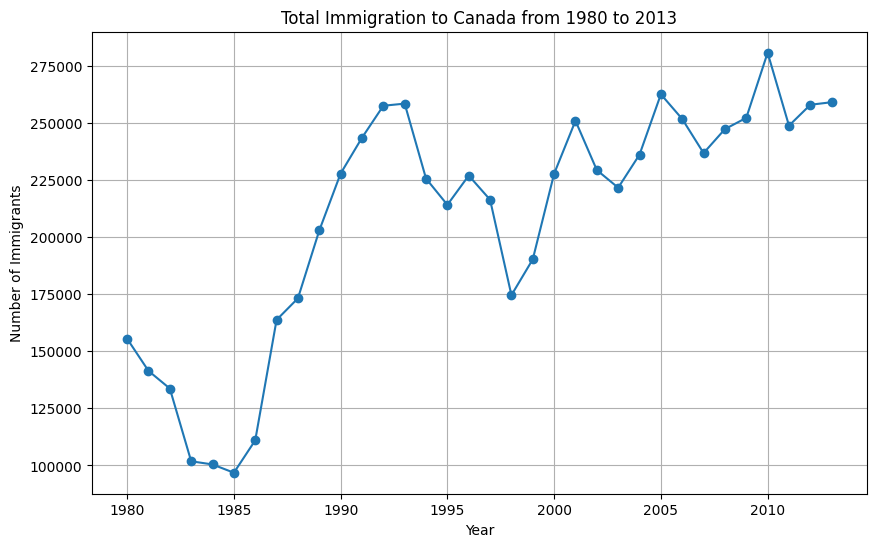

In [41]:
yearly_total_immigration = data_cleaned.iloc[:, 9:].sum()

# Preparing data for the plot
years = yearly_total_immigration.index.astype(int)
total_immigration = yearly_total_immigration.values

plt.figure(figsize=(10, 6))
plt.plot(years, total_immigration, marker='o')
plt.title('Total Immigration to Canada from 1980 to 2013')
plt.xlabel('Year')
plt.ylabel('Number of Immigrants')
plt.grid(True)
plt.show()